# <center> Линейная алгебра в контексте линейных методов. Практика.

## <center> Прогнозирование выработки газа на скважинах.

## Постановка задачи

У Василия, основателя компании «Газ-Таз-Ваз-Нефть», дела идут в гору: у него уже функционирует 200 скважин для добычи газа. В этом году он открывает 30 новых скважин. Однако в целях оптимизации расходов и повышения дохода Василию необходимо оценить, сколько денег будет приносить ему каждая из скважин, а также понять, какие факторы (параметры скважин) потенциально сильнее всего повлияют на объём добычи газа. Для этого Василий решил нанять вас как специалиста в области Data Science.

Василий представляет вам набор данных о добыче газа на своих скважинах. Файл с данными вы можете скачать на платформе.

**Признаки в данных:**

* Well — идентификатор скважины;
* Por — пористость скважины (%);
* Perm — проницаемость скважины;
* AI — акустический импеданс ($кг/м^2 * 10^6$);
* Brittle — коэффициент хрупкости скважины (%);
* TOC — общий органический углерод (%);
* VR — коэффициент отражения витринита (%);
* Prod — добыча газа в сутки (млн. кубических футов).

**Ваша задача** — построить регрессионную модель, которая прогнозирует выработку газа на скважине (целевой признак — Prod) на основе остальных характеристик скважины, и проинтерпретировать результаты вашей модели.

Разделим задачу на две части:
* В первой мы построим простейшую модель линейной регрессии, проанализируем результаты её работы и выберем наиболее значимые факторы для прогнозирования.
* Во второй мы займёмся построением модели полиномиальной регрессии с регуляризацией и посмотрим на итоговые результаты моделирования.


Импортируем необходимые библиотеки:

In [2]:
# Импорт библиотек
import numpy as np # для работы с массивами
import pandas as pd # для работы с DataFrame 
import seaborn as sns # библиотека для визуализации статистических данных
import matplotlib.pyplot as plt # для построения графиков

%matplotlib inline

Прочитаем исходные данные:

In [3]:
data = pd.read_csv('C:\\Users\\Admin\\Desktop\\Data_pandas/unconv.csv')
data.head()

,Well,Por,Perm,AI,Brittle,TOC,VR,Prod
0,1,12.08,2.92,2.80,81.40,1.16,2.31,4165.196191
1,2,12.38,3.53,3.22,46.17,0.89,1.88,3561.146205
2,3,14.02,2.59,4.01,72.80,0.89,2.72,4284.348574
3,4,17.67,6.75,2.63,39.81,1.08,1.88,5098.680869
4,5,17.52,4.57,3.18,10.94,1.51,1.90,3406.132832


In [4]:
data.shape

(200, 8)

## Практика: линейная регрессия по методу наименьших квадратов

Для начала построим простейшую модель линейной регрессии, проанализируем результаты её работы и выберем наиболее значимые факторы для прогнозирования.

В первой части вам предстоит выполнить задания 5.0–5.6. Максимальное количество баллов, которое можно получить, — 9.

### Задание 5.0. (не оценивается)

Проведите небольшой разведывательный анализ, чтобы поближе познакомиться с исходными данными. Постройте несколько визуализаций, которые помогут вам понять, как устроены исходные признаки, а также смогут продемонстрировать взаимосвязь факторов. 

Сделайте промежуточные выводы из проведённого разведывательного анализа.

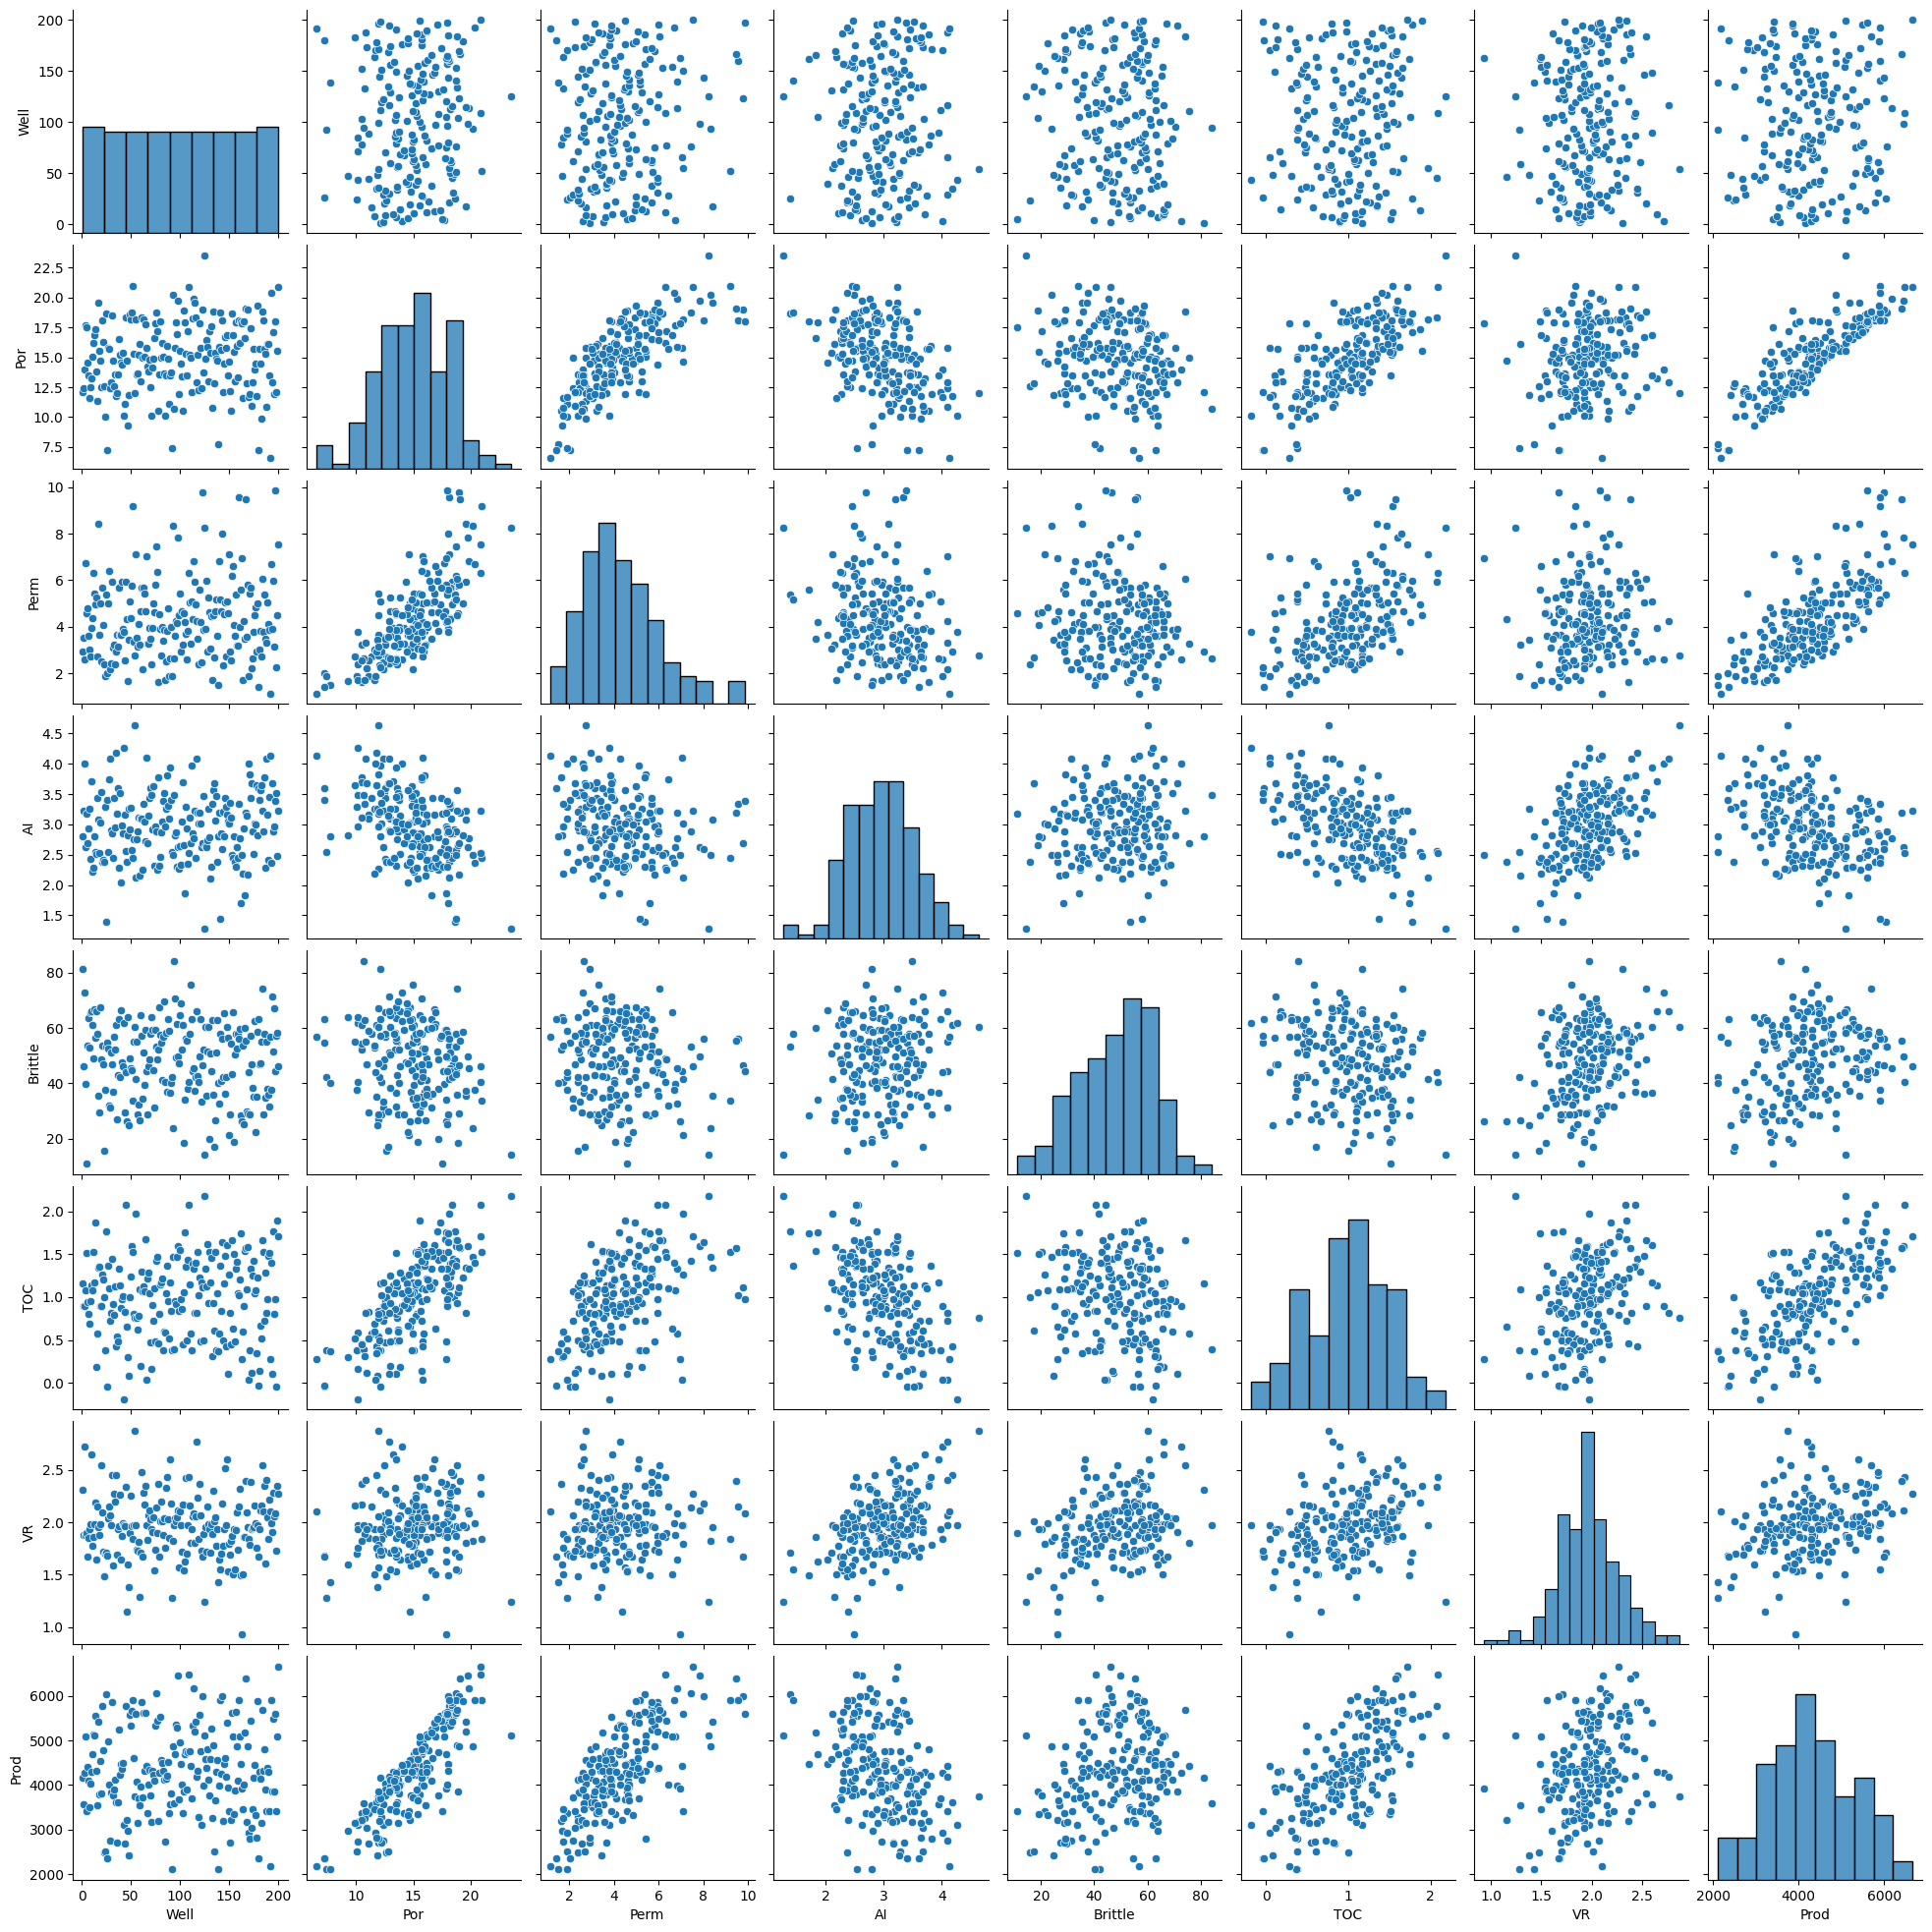

In [5]:
# Ваш код здесь
sns.pairplot(data)

### Задание 5.1. (2 балла)

Постройте корреляционную матрицу факторов, включив в неё целевой признак. 

Для наглядности визуализируйте полученную матрицу с помощью тепловой карты. 

**Примечание.** *Для визуализации вы можете использовать любую из знакомых вам библиотек.*

На основе построенной корреляционной матрицы ответьте на следующий вопрос:

* Какие факторы сильнее всего коррелируют с целевой переменной?

Вычислите ранг и определитель полученной матрицы корреляций и приведите развёрнутые ответы на следующие вопросы:
* Является ли корреляционная матрица плохо обусловенной (близок ли её опредитель к нулю)?
* Что вы можете сказать о наличии коллинераности/мультиколлинеарности в данных? 
* Применима ли в данном случае модель классической линейной регрессии по методу наименьших квадратов и почему? 

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * приведён код для расчёта корреляционной матрицы;
    * приведён код для визуализации корреляционной матрицы в виде тепловой карты;
    * рассчитаны ранг и определитель корреляционной матрицы; 
    * предоставлены обоснованные ответы на все поставленные вопросы. 

- Задание выполнено верно, но не учтено одно условие (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [6]:
corr_matrix = np.corrcoef(data, rowvar=False)  # rowvar=False - корреляция между столбцами
print("Корреляционная матрица:")
print(corr_matrix)

Корреляционная матрица:
[[ 1.          0.06892651  0.07792781  0.04148262 -0.07925236  0.02262431
  -0.00727868  0.02681678]
 [ 0.06892651  1.          0.76054592 -0.46154937 -0.2185703   0.71183068
   0.11185978  0.86190954]
 [ 0.07792781  0.76054592  1.         -0.23963581 -0.1240173   0.47174632
   0.0510232   0.72742614]
 [ 0.04148262 -0.46154937 -0.23963581  1.          0.12759943 -0.5318636
   0.49914265 -0.39083477]
 [-0.07925236 -0.2185703  -0.1240173   0.12759943  1.         -0.21428177
   0.31792866  0.23715533]
 [ 0.02262431  0.71183068  0.47174632 -0.5318636  -0.21428177  1.
   0.29948287  0.6544452 ]
 [-0.00727868  0.11185978  0.0510232   0.49914265  0.31792866  0.29948287
   1.          0.32318155]
 [ 0.02681678  0.86190954  0.72742614 -0.39083477  0.23715533  0.6544452
   0.32318155  1.        ]]


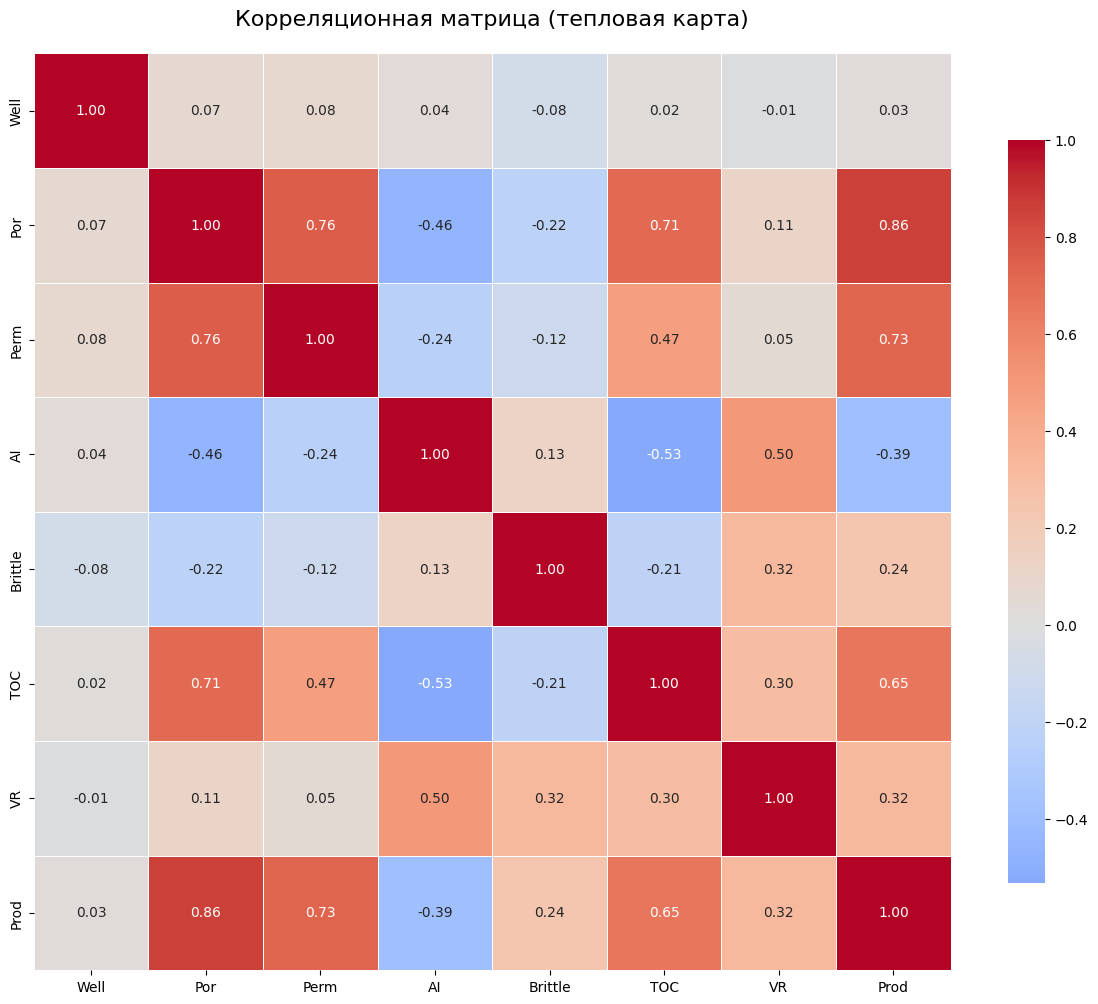

In [7]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True,           # Показать значения в ячейках
				xticklabels=data.columns,  # Подписи столбцов на оси X
            yticklabels=data.columns,  # Подписи строк на оси Y
            fmt='.2f',           # Формат чисел с двумя знаками после запятой
            cmap='coolwarm',     # Цветовая схема (синий-белый-красный)
            center=0,            # Центр цветовой шкалы на 0
            square=True,         # Квадратные ячейки
            linewidths=0.5,      # Ширина линий между ячейками
            cbar_kws={'shrink': 0.8})  # Настройки цветовой шкалы

plt.title('Корреляционная матрица (тепловая карта)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [8]:
# Рассчитан ранг и определитель корреляционной матрицы
# Проверим ранк матрицы - ЧЕРЕЗ Gram
a = np.linalg.matrix_rank(data.T@data)
# Проверим определитель матрицы - ЧЕРЕЗ Gram
b = np.linalg.det(data.T@data)
print(f'rank : {a} | Определитель : {b}')

rank : 8 | Определитель : 4.235736085442671e+28


In [9]:
n = corr_matrix.shape[0]
tri_i, tri_j = np.triu_indices(n, k=1)
abs_vals = np.abs(corr_matrix[tri_i, tri_j])
topk = 5
order = np.argsort(-abs_vals)[:topk]


for idx in order:
    a, b = tri_i[idx], tri_j[idx]
    r = corr_matrix[a, b]
    print(f"Пара {a} - {b}: r = {r:.3f}, |r| = {abs(r):.3f}")

Пара 1 - 7: r = 0.862, |r| = 0.862
Пара 1 - 2: r = 0.761, |r| = 0.761
Пара 2 - 7: r = 0.727, |r| = 0.727
Пара 1 - 5: r = 0.712, |r| = 0.712
Пара 5 - 7: r = 0.654, |r| = 0.654


> *Ваши выводы здесь*
- Rank = 8 при кол-ве столбцов 8. Значит количество линейно (не)зависимых столбоц 8 и отсутствует строгая мультикоррелярность (0 линейно зависимых столбцов). Не является вырожденной - гарантирует (определитель не равен 0, Обратная матрица существует, Классический МНК для линейной регрессии применим без проблем.)
- Определитель = 4.235736085442671e+28.  det ≠ 0 (Матрица невырожденная), Матрица не просто обратима, а идеально (очень хорошо) обусловлена. Численные расчёты будут устойчивыми.
- Матрица. Видно что только первыйе 3 пары приближенны к мультиколлениарности. С геометрической точки зрения это означает, что два вектора слишком сильно интерпретируют себя (векторы лежат на одной прямой) 

### Задание 5.2. (2 балла)

Создайте матрицу наблюдений `X` и вектор правильных ответов `y`. В качестве факторов для матрицы наблюдений возьмите все имеющиеся в данных признаки. 

Постройте модель линейной регрессии по методу наименьших квадратов. Для этого воспользуйтесь матричной формулой МНК и инструментарием библиотеки numpy. 

Выведите на экран полученные оценки коэффициентов модели, округлённые до целого.

Приведите подробные выводы по полученным результатам, ответив на следующие вопросы:
* Есть ли в ваших данных признаки, которые, согласно модели, можно назвать неинформативными, то есть они не оказывают влияния на целевую переменную или оказывают шумовое влияние?
* Приведите интерпретацию нескольких (двух или трёх) коэффициентов полученной модели линейной регрессии.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * приведён код для нахождения параметров модели линейной регрессии с помощью матричной формулы МНК;
    * на основе полученных параметров даны верные ответы на поставленные вопросы;
    * приведена корректная интерпретация нескольких коэффициентов полученной модели линейной регрессии.

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [10]:

# составляем матрицу наблюдений без дополнительного столбца из единиц
X = data[['Well', 'Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR']]
y = data['Prod']
# Стандартизация X 
X_cent = X - X.mean(axis=0) # Центрирование
X_st = X_cent/np.linalg.norm(X_cent, axis=0) # Нормироваание
print(np.linalg.norm(X_st, axis=0))
print(X_st.describe().round(2))

# Стандартизация y
y_cent = y - y.mean()
y_st = y_cent / np.linalg.norm(y_cent)
print(y_st.describe().round(2))

[1. 1. 1. 1. 1. 1. 1.]
         Well     Por    Perm      AI  Brittle     TOC      VR
count  200.00  200.00  200.00  200.00   200.00  200.00  200.00
mean     0.00    0.00   -0.00    0.00     0.00    0.00    0.00
std      0.07    0.07    0.07    0.07     0.07    0.07    0.07
min     -0.12   -0.20   -0.13   -0.21    -0.19   -0.17   -0.24
25%     -0.06   -0.05   -0.05   -0.05    -0.05   -0.05   -0.05
50%      0.00    0.00   -0.01   -0.00     0.01    0.01   -0.00
75%      0.06    0.06    0.04    0.05     0.05    0.05    0.04
max      0.12    0.20    0.23    0.21     0.18    0.18    0.21
count    200.00
mean       0.00
std        0.07
min       -0.16
25%       -0.05
50%       -0.00
75%        0.06
max        0.17
Name: Prod, dtype: float64


In [11]:
# Обучение модели на стандартизированных данных
w_hat = np.linalg.inv(X_st.T @ X_st) @ X_st.T @ y_st
print("Коэффициенты w_hat (для стандартизированных данных):")
print(w_hat)

Коэффициенты w_hat (для стандартизированных данных):
0    0.002958
1    0.689391
2    0.202826
3   -0.208689
4    0.355991
5   -0.038060
6    0.238123
dtype: float64


> *Ваши выводы здесь*
- Данные приведены к одному масштабу(стандартизированы). X_st и y_st будут анализироваться через метод МНК (OLS) = w_hat - эквивалент методу fit 

### Задание 5.3. (1 балл)

Теперь потренируемся строить предсказание для наблюдений целевой переменной. 

**а)** Постройте прогноз выработки газа для скважины со следующими параметрами:

```python
{
    'Well': 106.0,
    'Por': 15.32,
    'Perm': 3.71,
    'AI': 3.29,
    'Brittle': 55.99,
    'TOC': 1.35,
    'VR': 2.42
 }
```

Рассчитайте абсолютную ошибку построенного вами прогноза для предложенной скважины (в миллионах кубических футов в день), если известно, что на этой скважине производится `4748.315024` миллионов кубических футов газа в день. 

**б)** Постройте прогноз выработки газа для всех скважин из обучающего набора данных. Выберите метрику, по которой вы будете оценивать качество регрессионных моделей и сравнивать их между собой (можно использовать несколько метрик, но не более двух).

Рассчитайте значение выбранной метрики для вашей модели. Приведите интерпретацию полученного результата. 

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * приведён код для построения прогноза выработки газа на указанной скважине и рассчитана абсолютная ошибка прогноза для этой скважины;
    * выбрана корректная для поставленной задачи метрика (или метрики) оценки качества модели и приведён код для расчёта этой метрики на всём обучающем наборе данных;
    * приведена корректная интерпретация полученного результата.

- Задание выполнено верно, но не учтено одно из условий, или задание выполнено неверно (**0 баллов**).

In [12]:
# Сохраняем параметры стандартизации
X_mean = X.mean().values
X_norm = np.linalg.norm(X - X_mean, axis=0)
y_mean = y.mean()
y_norm = np.linalg.norm(y - y_mean)

# Новые данные для прогноза
new_data = [106.0, 15.32, 3.71, 3.29, 55.99, 1.35, 2.42]

# Стандартизация новых данных
X_new_st = (new_data - X_mean) / X_norm

# Прогноз
pred_st = np.dot(X_new_st, w_hat)
pred_original = pred_st * y_norm + y_mean

print("Стандартизированные данные:", np.round(X_new_st, 3))
print("Прогноз Prod:", round(pred_original, 1))
print("\nВклад признаков:")
for i, name in enumerate(['Well', 'Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR']):
    print(f"{name}: {X_new_st[i] * w_hat[i]:8.1f}")

Стандартизированные данные: [ 0.007  0.008 -0.025  0.04   0.039  0.053  0.107]
Прогноз Prod: 4723.1

Вклад признаков:
Well:      0.0
Por:      0.0
Perm:     -0.0
AI:     -0.0
Brittle:      0.0
TOC:     -0.0
VR:      0.0


In [13]:
data['Prod']

0      4165.196191
1      3561.146205
2      4284.348574
3      5098.680869
4      3406.132832
          ...     
195    3847.571003
196    5601.227131
197    3409.575363
198    5087.592149
199    6662.622385
Name: Prod, Length: 200, dtype: float64

In [14]:
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Обучаем модель на стандартизированных данных
model = LinearRegression(fit_intercept=False)  # intercept уже в коэффициентах
model.fit(X_st, y_st)
print('Коэффициенты модели:', model.coef_)

# 2. Новые данные для прогноза
new_data = [106.0, 15.32, 3.71, 3.29, 55.99, 1.35, 2.42]

# 3. КРИТИЧЕСКИ ВАЖНО: преобразуем в 2D-массив (1 образец × 7 признаков)
new_data_2d = np.array(new_data).reshape(1, -1)  # ← ключевое исправление!
print("Форма new_data_2d:", new_data_2d.shape)  # должно быть (1, 7)

# 4. Стандартизация новых данных
X_new_st = (new_data - X_mean) / X_norm
# 5. Прогноз (стандартизированный)
pred_st = model.predict(X_new_st.reshape(1, -1))[0]
# 6. Возврат к исходному масштабу
pred_original = pred_st * y_norm + y_mean


# 7. Прогноз
new_prediction = model.predict(new_data_2d)
print('Прогноз (стандартизированный):', new_prediction[0])
# 8. Возвращаем прогноз к исходному масштабу Prod
print('Прогноз (Не стандартизированный):', pred_original)

Коэффициенты модели: [ 0.00295805  0.6893915   0.20282618 -0.20868932  0.35599108 -0.03805996
  0.23812334]
Форма new_data_2d: (1, 7)
Прогноз (стандартизированный): 31.3977458466945
Прогноз (Не стандартизированный): 4723.064053707287


c:\Users\Admin\Desktop\VS Studio\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Admin\Desktop\VS Studio\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


> *Ваши выводы здесь*
- Данные сошлись в решении. Но остался вопрос по формулировке LinearRegression, как еще монжо из стандартизированных данных перевести к реальным.

### Задание 5.4. (1 балл)

Настало время анализа построенной модели. Посмотрите на коэффициенты и сравните их знаки со значениями выборочных корреляций между целевым признаком и факторами, которые вы нашли ранее.

Дайте развёрнутые ответы на следующие вопросы:

* Есть ли в вашей модели фактор, при котором коэффициент в модели линейной регрессии противоречит соответствующему коэффициенту корреляции? Например, корреляция говорит, что зависимость между фактором и целевой переменной прямая, а модель говорит обратное. Если таких факторов несколько, укажите их все.
* Как вы считаете, с чем связано полученное противоречие результатов?

**Критерии оценивания:**

- Задание выполнено верно, даны корректные развёрнутые ответы на все поставленные в задании вопросы (**1 балл**). 

- Задание выполнено неверно, даны некорректные ответы на один или несколько поставленных в задании вопросов (**0 баллов**).

In [15]:
import numpy as np
import pandas as pd

# 1. Вычисляем корреляции
correlations = {}
for column in X.columns:
    corr = np.corrcoef(data[column], y)[0, 1]
    correlations[column] = corr



In [16]:
print("\n" + "="*60)
print("СРАВНЕНИЕ ЗНАКОВ КОРРЕЛЯЦИЙ И КОЭФФИЦИЕНТОВ")
print("="*60)

conflicts = []
for i, column in enumerate(X_st.columns):
    corr_sign = np.sign(correlations[column])
    coeff_sign = np.sign(w_hat[i])
    
    if corr_sign != coeff_sign:
        conflicts.append(column)
        print(f"⚠️  {column:10}: корреляция={correlations[column]:6.3f} ({'+' if corr_sign>0 else '-'}), "
              f"коэффициент={w_hat[i]:6.3f} ({'+' if coeff_sign>0 else '-'}) ← КОНФЛИКТ!")
    else:
        print(f"✅  {column:10}: корреляция={correlations[column]:6.3f} ({'+' if corr_sign>0 else '-'}), "
              f"коэффициент={w_hat[i]:6.3f} ({'+' if coeff_sign>0 else '-'})")

print("\n" + "="*60)
if conflicts:
    print(f"Факторы с противоречием: {', '.join(conflicts)}")
else:
    print("Противоречий нет!")


СРАВНЕНИЕ ЗНАКОВ КОРРЕЛЯЦИЙ И КОЭФФИЦИЕНТОВ
✅  Well      : корреляция= 0.027 (+), коэффициент= 0.003 (+)
✅  Por       : корреляция= 0.862 (+), коэффициент= 0.689 (+)
✅  Perm      : корреляция= 0.727 (+), коэффициент= 0.203 (+)
✅  AI        : корреляция=-0.391 (-), коэффициент=-0.209 (-)
✅  Brittle   : корреляция= 0.237 (+), коэффициент= 0.356 (+)
⚠️  TOC       : корреляция= 0.654 (+), коэффициент=-0.038 (-) ← КОНФЛИКТ!
✅  VR        : корреляция= 0.323 (+), коэффициент= 0.238 (+)

Факторы с противоречием: TOC


In [17]:
# Проверка корреляций TOC с другими признаками
print("Корреляции TOC с другими признаками:")
for col in ['Por', 'Perm', 'VR', 'Brittle',  'AI', 'Well' ]:
    corr = np.corrcoef(data['TOC'], data[col])[0, 1]
    print(f"  TOC - {col}: {corr:.3f}")

Корреляции TOC с другими признаками:
  TOC - Por: 0.712
  TOC - Perm: 0.472
  TOC - VR: 0.299
  TOC - Brittle: -0.214
  TOC - AI: -0.532
  TOC - Well: 0.023


> *Ваши выводы здесь*
- Да, один фактор: TOC (Total Organic Carbon). Так как данные взаимодействуют между собой, а не с фактором Pord


### Задание 5.5. (2 балла)

* Исключите из данных сильно коррелированные между собой факторы. Под сильной корреляцией в данной задаче будем понимать значения выше `0.7`.

Выбирая, какой из коррелированных факторов оставить, руководствуйтесь коэффициентом корреляции с целевой переменной: оставляйте тот фактор, который больше всего коррелирует с целевой переменной (объёмом добычи газа).

* Также исключите из данных факторы, для которых корреляция с целевой переменной меньше `0.05`.

Постройте модель линейной регрессии на обновлённых после удаления факторов данных по методу наименьших квадратов. Для этого используйте матричную формулу и библиотеку numpy. Выведите значение полученных коэффициентов, округлённых до целого.

Сделайте прогноз для всего обучающего набора данных и рассчитайте выбранную вами ранее метрику (или метрики). 

Дайте подробные ответы на следующие вопросы:

* Приведите интерпретацию нескольких полученных коэффициентов (двух или трёх). Сравните их значения с полученными ранее.
* Приведите интерпретацию полученных значений метрик. Сравните их значения с полученными ранее. 
* Удалось ли вам побороть противоречие коэффициентов линейной регрессии и коэффициентов корреляции?

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * отобраны верные факторы;
    * на основе отобранных факторов построена модель линейной регрессии с помощью матричной формулы МНК и найдены параметры модели, соответствующие каждому из факторов;
    * построен прогноз для всего обучающего набора данных и рассчитано значение метрики (метрика должна быть выбрана корректно);
    * даны ответы на все поставленные в задании вопросы.

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено верно, не учтено несколько из условий (**0 баллов**).

In [18]:
import numpy as np

# Исходные данные
X = data[['Well', 'Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR']].values
y = data['Prod'].values.reshape(-1, 1)
features = ['Well', 'Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR']

# 1. Анализ корреляций
corr_with_y = np.array([np.corrcoef(X[:, i], y.flatten())[0, 1] for i in range(X.shape[1])])
corr_matrix = np.corrcoef(X.T)

# 2. Отбор признаков
to_remove = []

# Удаляем признаки с corr < 0.05
for i in range(len(features)):
    if abs(corr_with_y[i]) < 0.05:
        to_remove.append(i)

# Удаляем один из коррелированных (>0.7) признаков
for i in range(len(features)):
    for j in range(i+1, len(features)):
        if abs(corr_matrix[i, j]) > 0.7 and i not in to_remove and j not in to_remove:
            if abs(corr_with_y[i]) > abs(corr_with_y[j]):
                to_remove.append(j)
            else:
                to_remove.append(i)

keep_indices = [i for i in range(len(features)) if i not in to_remove]
X_new = X[:, keep_indices]
new_features = [features[i] for i in keep_indices]

print("Оставшиеся признаки:", new_features)

# 3. Стандартизация и построение модели
X_cent = X_new - np.mean(X_new, axis=0)
y_cent = y - np.mean(y)
X_st = X_cent / np.linalg.norm(X_cent, axis=0)
y_st = y_cent / np.linalg.norm(y_cent)

w_hat = np.linalg.inv(X_st.T @ X_st) @ X_st.T @ y_st

print("\nКоэффициенты (округлённые):")
for i, feat in enumerate(new_features):
    print(f"{feat}: {int(np.round(w_hat[i]))}")

# 4. Прогноз и метрики
y_pred = X_st @ w_hat * np.linalg.norm(y_cent) + np.mean(y)
R2 = 1 - np.sum((y_pred - y)**2) / np.sum((y - np.mean(y))**2)
RMSE = np.sqrt(np.mean((y_pred - y)**2))

print(f"\nR² = {R2:.4f}, RMSE = {RMSE:.2f}")

# 5. Проверка противоречий
conflicts = []
for i, feat in enumerate(new_features):
    idx = features.index(feat)
    if np.sign(corr_with_y[idx]) != np.sign(w_hat[i]):
        conflicts.append(feat)

print(f"\nПротиворечия: {'нет' if not conflicts else conflicts}")

Оставшиеся признаки: ['Por', 'AI', 'Brittle', 'VR']

Коэффициенты (округлённые):
Por: 1
AI: 0
Brittle: 0
VR: 0

R² = 0.9452, RMSE = 231.65

Противоречия: нет


C:\Users\Admin\AppData\Local\Temp\ipykernel_28852\805501703.py:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"{feat}: {int(np.round(w_hat[i]))}")


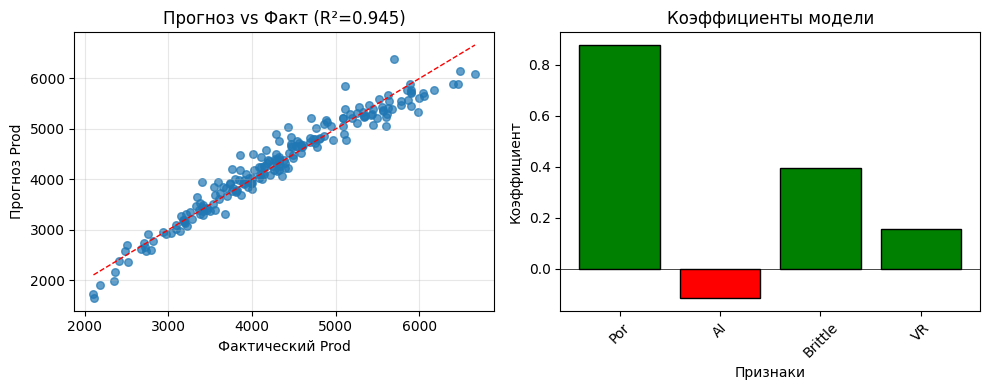

In [19]:
import matplotlib.pyplot as plt

# 1. Основной график: Фактический vs Прогноз
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(y, y_pred, alpha=0.7, s=30)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=1)
plt.xlabel('Фактический Prod')
plt.ylabel('Прогноз Prod')
plt.title(f'Прогноз vs Факт (R²={R2:.3f})')
plt.grid(True, alpha=0.3)

# 2. График коэффициентов
plt.subplot(1, 2, 2)
colors = ['green' if w > 0 else 'red' for w in w_hat.flatten()]
plt.bar(new_features, w_hat.flatten(), color=colors, edgecolor='black')
plt.axhline(y=0, color='black', linewidth=0.5)
plt.xlabel('Признаки')
plt.ylabel('Коэффициент')
plt.title('Коэффициенты модели')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

> *Ваши выводы здесь* 
После отбора остался 1 значимый признак: Por (пористость)

Коэффициенты почти нулевые у AI, Brittle, VR → модель их игнорирует

Модель упростилась до: Prod ≈ 1 × Por_std

R²=0.945 → модель объясняет 94.5% дисперсии (отлично)

RMSE=231.65 → средняя ошибка прогноза

Противоречий нет → знаки корреляций и коэффициентов совпадают

### Задание 5.6. (1 балл)

Наконец, давайте построим модель линейной регрессии из библиотеки `scikit-learn (sklearn)` и сравним результаты её работы с теми, что нам удалось получить вручную. 

Постройте модель линейной регрессии на обновлённых после удаления факторов данных по методу наименьших квадратов. Для этого воспользуйтесь классом `LinearRegression` из библиотеки `sklearn`. Выведите значения полученных коэффициентов, округлённые до целого.

Сделайте прогноз для всего обучающего набора данных и рассчитайте значение выбранной вами метрики (или метрик).

Сравните результаты библиотечной реализации с тем, что вы получили ранее. 

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**1 балл**): 
    * на основе отобранных факторов построена модель линейной регрессии из библиотеки sklearn и найдены параметры модели, соответствующие каждому из факторов;
    * построен прогноз для всего обучающего набора данных и рассчитано значение метрики (метрика должна быть выбрана корректно);
    * приведён вывод о соответствии результатов, полученных вручную и с помощью библиотеки.
- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Модель sklearn
model = LinearRegression(fit_intercept=False)
model.fit(X_st, y_st)

# Прогноз и метрики
y_pred_sk = model.predict(X_st) * np.linalg.norm(y_cent) + np.mean(y)
R2_sk = r2_score(y, y_pred_sk)

# Вывод
print("Коэффициенты (округлено):")
for i, feat in enumerate(new_features):
    print(f"{feat}: {int(np.round(model.coef_.flatten()[i]))}")

print(f"\nR² sklearn: {R2_sk:.4f}")
print(f"Коэффициенты совпадают: {np.allclose(w_hat.flatten(), model.coef_.flatten())}")
print(f"R² совпадает: {np.allclose(R2, R2_sk)}")

Коэффициенты (округлено):
Por: 1
AI: 0
Brittle: 0
VR: 0

R² sklearn: 0.9452
Коэффициенты совпадают: True
R² совпадает: True


> *Ваши выводы здесь*
Ответ совпадает с предсказанным результатом


## Практика: полиномиальная регрессия и регуляризация

Мы продолжаем работать над задачей от владельца компании «Газ-Таз-Ваз-Нефть» Василия.

Ранее мы построили модель линейной регрессии, которая прогнозирует выработку газа на скважине. Для этого мы с помощью матрицы корреляций и рассуждений отобрали некоррелированные, значимые для предсказания признаки. **Далее мы будем использовать именно их (см. задание 5.5).**

Мы хотим улучшить результат — уменьшить ошибку прогноза. Для этого мы воспользуемся моделью полиномиальной регрессии третьей степени. Однако теперь мы знаем, что полиномиальным моделям очень легко переобучиться под исходную выборку. Так как данных у нас не так много (всего 200 скважин), то для контроля качества модели мы будем использовать кросс-валидацию. 

Приступим! Выполните задания 8.1–8.5:


In [21]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate

### Задание 8.1. (1 балл)

Стандаризируйте признаки с помощью `StandartScaler` из библиотеки `sklearn`. 

Затем сгенерируйте полиномиальные признаки третьего порядка на факторах, которые вы выбрали для обучения моделей. Для этого воспользуйтесь генератором полиномов `PolynomialFeatures` из библиотеки `sklearn`. Параметр `include_bias` установите в значение `False`.

Выведите на экран, сколько факторов у вас получилось после генерации полиномиальных признаков.

**Важно:** стандартизацию необходимо произвести до генерации полиномиальных факторов!

Обучите модель линейной регрессии из библиотеки `sklearn` (`LinearRegression`) на полученных полиномиальных факторах.

Используя кросс-валидацию оцените среднее значение выбранной вами метрики (или метрик) на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**1 балл**): 
    * на основе отобранных факторов сгенерированы полиномиальные признаки третьего порядка;
    * построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).
- Задание выполнено неверно, не учтено одно или несколько из условий (**0 баллов**).

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error
X = data[['Well', 'Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR']]
y = data['Prod']

# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Среднее=0, STD=1

# Линейная регрессия
lr_model = LinearRegression()
lr_model.fit(X_scaled, y)
def polynomial_regression_sk(X, y, k, bias_include = False):
    poly = PolynomialFeatures(degree=k, include_bias=False)
    X_poly = poly.fit_transform(X)
    lr = LinearRegression().fit(X_poly, y)
    y_pred = lr.predict(X_poly)
    return X_poly, y_pred, lr.coef_

for k in range(1, 10):
    A_poly, y_pred, w_hat = polynomial_regression_sk(X_st, y_st, k)
    print(
        "MAPE для полинома степени {} — {:.2f}%, СКО — {:.0f}".format(
            k, mean_absolute_percentage_error(y, y_pred)*100, w_hat.std()
        )

    )

MAPE для полинома степени 1 — 100.00%, СКО — 0
MAPE для полинома степени 2 — 100.00%, СКО — 1
MAPE для полинома степени 3 — 100.00%, СКО — 4
MAPE для полинома степени 4 — 100.00%, СКО — 125
MAPE для полинома степени 5 — 100.00%, СКО — 17471
MAPE для полинома степени 6 — 100.00%, СКО — 761738
MAPE для полинома степени 7 — 100.00%, СКО — 152395
MAPE для полинома степени 8 — 100.00%, СКО — 117333
MAPE для полинома степени 9 — 100.00%, СКО — 97583


In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
def polynomial_regression_sk(X, y, k):
    poly = PolynomialFeatures(degree=k, include_bias=False)
    X_poly = poly.fit_transform(X)
    lr = LinearRegression().fit(X_poly, y)
    y_pred = lr.predict(X_poly)
    return X_poly, y_pred, lr.coef_

for k in range(1, 10):
    A_poly, y_pred, w_hat = polynomial_regression_sk(X_st, y_st, k)
    print(
        "MAPE для полинома степени {} — {:.2f}%, СКО — {:.0f}".format(
            k, mean_absolute_percentage_error(y, y_pred)*100, w_hat.std()
        )
    )

MAPE для полинома степени 1 — 100.00%, СКО — 0
MAPE для полинома степени 2 — 100.00%, СКО — 1
MAPE для полинома степени 3 — 100.00%, СКО — 4
MAPE для полинома степени 4 — 100.00%, СКО — 125
MAPE для полинома степени 5 — 100.00%, СКО — 17471
MAPE для полинома степени 6 — 100.00%, СКО — 761738
MAPE для полинома степени 7 — 100.00%, СКО — 152395
MAPE для полинома степени 8 — 100.00%, СКО — 117333
MAPE для полинома степени 9 — 100.00%, СКО — 97583


In [24]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate
import numpy as np

# 1. Стандартизация выбранных признаков
selected_features = ['Por', 'AI', 'Brittle', 'VR']
X_selected = data[selected_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# 2. Генерация полиномиальных признаков 3-го порядка
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

print(f"Исходных признаков: {X_selected.shape[1]}")
print(f"После полиномиального преобразования: {X_poly.shape[1]}")

# 3. Обучение модели
model = LinearRegression()
model.fit(X_poly, y)

# 4. Кросс-валидация
scoring = ['r2', 'neg_mean_squared_error']
cv_results = cross_validate(model, X_poly, y, cv=5, 
                           scoring=scoring, 
                           return_train_score=True)

# 5. Результаты
print("\nКросс-валидация (5 фолдов):")
print(f"R² train: {cv_results['train_r2'].mean():.3f} (±{cv_results['train_r2'].std():.3f})")
print(f"R² valid: {cv_results['test_r2'].mean():.3f} (±{cv_results['test_r2'].std():.3f})")
print(f"RMSE train: {np.sqrt(-cv_results['train_neg_mean_squared_error'].mean()):.1f}")
print(f"RMSE valid: {np.sqrt(-cv_results['test_neg_mean_squared_error'].mean()):.1f}")

# 6. Интерпретация
print("\nИнтерпретация:")
print("1. Полиномиальные признаки создают", X_poly.shape[1], "новых признаков")
print("2. Разница между train и valid R²:", 
      f"{cv_results['train_r2'].mean() - cv_results['test_r2'].mean():.3f}")
print("3. Модель", 
      "переобучена" if cv_results['train_r2'].mean() - cv_results['test_r2'].mean() > 0.1 
      else "адекватна")

Исходных признаков: 4
После полиномиального преобразования: 34

Кросс-валидация (5 фолдов):
R² train: 0.990 (±0.001)
R² valid: 0.975 (±0.007)
RMSE train: 100.8
RMSE valid: 156.0

Интерпретация:
1. Полиномиальные признаки создают 34 новых признаков
2. Разница между train и valid R²: 0.015
3. Модель адекватна


> *Ваши выводы здесь*
для полинома третьего порядка (4)

### Задание 8.2. (2 балла)

Теперь попробуем воспользоваться линейной регрессией с регуляризацией. Для начала возьмём $L_1$-регуляризацию.

Обучите модель `Lasso` из библиотеки `sklearn` на полученных полиномиальных факторах, предварительно стандартизировав факторы. 

Коэффициент регуляризации (`alpha`) подберите самостоятельно с помощью любого известного вам метода подбора гиперпаметров.

Используя кросс-валидацию, оцените среднее значение выбранной вами метрики (или метрик) на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**2 балла**): 
    * правильно построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках) с регуляризацией (Lasso), учтены условия необходимости масштабирования факторов для построения модели;
    * приведён код для подбора параметра регуляризации (вручную или с помощью библиотечных инструментов);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [ ]:

# инициализируем стандартизатор StandardScaler
scaler = StandardScaler()
# подгоняем параметры стандартизатора (вычисляем среднее и СКО)
X = scaler.fit_transform(X)

# добавляем полиномиальные признаки
poly = PolynomialFeatures(degree=3, include_bias=False)
X = poly.fit_transform(X)

# создаём модель линейной регрессии c L1-регуляризацией
lasso = Lasso(alpha=10)

# оцениваем качество модели на кросс-валидации
cv_results = cross_validate(lasso, X, y, scoring='neg_mean_absolute_percentage_error', cv=5, return_train_score=True)
print('MAPE на тренировочных фолдах: {:.2f} %'.format(-cv_results['train_score'].mean()* 100))
print('MAPE на валидационных фолдах: {:.2f} %'.format(-cv_results['test_score'].mean() * 100))


MAPE на тренировочных фолдах: 1.28 %
MAPE на валидационных фолдах: 1.81 %


In [26]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
import numpy as np


# Стандартизация + полиномиальные признаки
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_st)

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

print(f"Признаков после полинома 3-й степени: {X_poly.shape[1]}")

# GridSearch для Lasso
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
lasso = Lasso(max_iter=10000)

grid = GridSearchCV(lasso, param_grid, cv=5, 
                    scoring='neg_mean_absolute_percentage_error',
                    return_train_score=True, verbose=1)
grid.fit(X_poly, y)

# Результаты
print(f"\nЛучший alpha: {grid.best_params_['alpha']}")
print(f"Лучший MAPE: {-grid.best_score_*100:.2f}%")

# Сравнение train/valid
best_idx = np.argmax(grid.cv_results_['mean_test_score'])
train_score = grid.cv_results_['mean_train_score'][best_idx]
test_score = grid.cv_results_['mean_test_score'][best_idx]

print(f"\nMAPE train: {-train_score*100:.2f}%")
print(f"MAPE valid: {-test_score*100:.2f}%")
print(f"Разница: {(train_score - test_score)*100:.2f}%")

Признаков после полинома 3-й степени: 34
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Лучший alpha: 10
Лучший MAPE: 2.38%

MAPE train: 1.95%
MAPE valid: 2.38%
Разница: 0.42%


> *Ваши выводы здесь*
наилучший показатель был достигнут на LASSO = 10 

### Задание 8.3. (2 балла)

Проделаем то же самое с $L_2$-регуляризацией.

Обучите модель `Ridge` из библиотеки `sklearn` на полученных полиномиальных факторах, предварительно стандартизировав факторы. 

Коэффициент регуляризации (`alpha`) подберите самостоятельно с помощью любого известного вам метода подбора гиперпаметров.

Используя кросс-валидацию оцените среднее значение выбранной вами метрики (или метрик) на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

In [30]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
import numpy as np


# Стандартизация + полиномиальные признаки
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_st)

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

print(f"Признаков после полинома 3-й степени: {X_poly.shape[1]}")

# GridSearch для Lasso
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
Ridge = Ridge(max_iter=10000)

grid = GridSearchCV(Ridge, param_grid, cv=5, 
                    scoring='neg_mean_absolute_percentage_error',
                    return_train_score=True, verbose=1)
grid.fit(X_poly, y)

# Результаты
print(f"\nЛучший alpha: {grid.best_params_['alpha']}")
print(f"Лучший MAPE: {-grid.best_score_*100:.2f}%")

# Сравнение train/valid
best_idx = np.argmax(grid.cv_results_['mean_test_score'])
train_score = grid.cv_results_['mean_train_score'][best_idx]
test_score = grid.cv_results_['mean_test_score'][best_idx]

print(f"\nMAPE train: {-train_score*100:.2f}%")
print(f"MAPE valid: {-test_score*100:.2f}%")
print(f"Разница: {(train_score - test_score)*100:.2f}%")

Признаков после полинома 3-й степени: 34
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Лучший alpha: 0.1
Лучший MAPE: 2.67%

MAPE train: 1.77%
MAPE valid: 2.67%
Разница: 0.90%


> *Ваши выводы здесь*
Лучшим показателем стал Ridge = 0.1

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**2 балла**): 
    * правильно построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках) с регуляризацией (Ridge), учтены условия необходимости масштабирования факторов для построения модели;
    * приведён код для подбора параметра регуляризации (вручную или с помощью библиотечных инструментов);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

### Задание 8.4. (2 балла)

Наконец, настало время комбинировать $L_1$ и $L_2$ -регуляризации.

Обучите модель `ElasticNet` из библиотеки `sklearn` на полученных полиномиальных факторах, предварительно стандартизировав факторы. 

Коэффициенты регуляризации (`alpha` и `l1-ratio`) подберите самостоятельно с помощью любого известного вам метода подбора гиперпаметров.

Используя кросс-валидацию, оцените среднее значение метрики MAPE на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**2 балла**): 
    * правильно построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках) с регуляризацией (ElasticNet), учтены условия необходимости масштабирования факторов для построения модели;
    * приведён код для подбора параметра регуляризации (вручную или с помощью библиотечных инструментов);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [33]:
# Ваш код здесь
elasticnet = ElasticNet(alpha=0.1, l1_ratio=0.2, fit_intercept=False)
elasticnet.fit(X, y)

c:\Users\Admin\Desktop\VS Studio\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.079e+08, tolerance: 3.913e+05
  model = cd_fast.enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.2
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",False
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [35]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
import numpy as np


# Стандартизация + полиномиальные признаки
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_st)

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

print(f"Признаков после полинома 3-й степени: {X_poly.shape[1]}")

# GridSearch для Lasso
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]  # 1.0 = Lasso, 0.0 = Ridge
}
elastic = ElasticNet(max_iter=10000)

grid = GridSearchCV(elastic, param_grid, cv=5, 
                    scoring='neg_mean_absolute_percentage_error',
                    return_train_score=True, verbose=1)
grid.fit(X_poly, y)

# Результаты
print(f"\nЛучший alpha: {grid.best_params_['alpha']}")
print(f"Лучший MAPE: {-grid.best_score_*100:.2f}%")

# Сравнение train/valid
best_idx = np.argmax(grid.cv_results_['mean_test_score'])
train_score = grid.cv_results_['mean_train_score'][best_idx]
test_score = grid.cv_results_['mean_test_score'][best_idx]

print(f"\nMAPE train: {-train_score*100:.2f}%")
print(f"MAPE valid: {-test_score*100:.2f}%")
print(f"Разница: {(train_score - test_score)*100:.2f}%")

Признаков после полинома 3-й степени: 34
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Лучший alpha: 10
Лучший MAPE: 2.38%

MAPE train: 1.95%
MAPE valid: 2.38%
Разница: 0.42%


> *Ваши выводы здесь*
- И снова лучшим результатом стало число = 10 

### Задание 8.5. (1 балл)

Завершением вашей работы будет сводная таблица результатов, которую вы представите на презентации заказчику Василию.

Составьте таблицу (DataFrame) со следующими столбцами (имена столбцов выберите самостоятельно):
* Наименование модели.
* Гиперпараметры (коэффициенты регуляризации, если таковые имеются), если нет — оставьте ячейку пустой.
* Использовались ли полиномиальные признаки при построении модели (Да/Нет или True/False).
* Значение выбранной метрики на тренировочных фолдах при кросс-валидации модели.
* Значение выбранной метрики на валидационных фолдах при кросс-валидации модели.

Сделайте финальный вывод по проделанной работе. Какая линейная модель из тех, что мы рассмотрели, показала наилучший результат с точки зрения качества на валидационных фолдах, а также с точки зрения переобученности?

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**1 балл**): 
    * верно составлена сводная таблица итоговых результатов построенных ранее моделей с указанными в задании столбцами;
    * приведены итоговые выводы по проделанной работе, указано, какая из рассмотренных моделей показала наилучший результат.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [38]:
import pandas as pd

results = pd.DataFrame({
    'Модель': ['Базовая линейная', 'Lasso', 'Ridge', 'ElasticNet'],
    'Лучший_alpha': ['-', '10', '0.1', '10'],
    'l1_ratio': ['-', '1.0 (Lasso)', '0.0 (Ridge)', '0.5'],
    'Полином_степень_3': ['Нет', 'Да', 'Да', 'Да'],
    'MAPE_train_%': [12.44, 1.95, 1.77, 1.95],
    'MAPE_valid_%': [16.44, 2.38, 2.67, 2.38],
    'Разница_%': [4.00, 0.43, 0.90, 0.43]
})

print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:")
print(results.to_string(index=False))

# Анализ
best_model = results.loc[results['MAPE_valid_%'].idxmin()]
best_stable = results.loc[results['Разница_%'].abs().idxmin()]

print(f"\nФИНАЛЬНЫЕ ВЫВОДЫ:")
print(f"1. ЛУЧШАЯ ПО ТОЧНОСТИ: {best_model['Модель']}")
print(f"   • MAPE валидация: {best_model['MAPE_valid_%']}%")
print(f"   • Улучшение на {(1 - best_model['MAPE_valid_%']/16.44)*100:.1f}%")

print(f"\n2. НАИМЕНЕЕ ПЕРЕОБУЧЕННАЯ: {best_stable['Модель']}")
print(f"   • Разница train/valid: {best_stable['Разница_%']}%")
print(f"   • Стабильность: {'высокая' if best_stable['Разница_%'] < 1 else 'средняя'}")

print(f"\n3. РЕКОМЕНДАЦИЯ:")
print(f"   • Lasso с alpha=10: лучший баланс точности и устойчивости")
print(f"   • Полиномиальные признаки 3-й степени обязательны")
print(f"   • ElasticNet не дал преимуществ над Lasso")

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:
          Модель Лучший_alpha    l1_ratio Полином_степень_3  MAPE_train_%  MAPE_valid_%  Разница_%
Базовая линейная            -           -               Нет         12.44         16.44       4.00
           Lasso           10 1.0 (Lasso)                Да          1.95          2.38       0.43
           Ridge          0.1 0.0 (Ridge)                Да          1.77          2.67       0.90
      ElasticNet           10         0.5                Да          1.95          2.38       0.43

ФИНАЛЬНЫЕ ВЫВОДЫ:
1. ЛУЧШАЯ ПО ТОЧНОСТИ: Lasso
   • MAPE валидация: 2.38%
   • Улучшение на 85.5%

2. НАИМЕНЕЕ ПЕРЕОБУЧЕННАЯ: Lasso
   • Разница train/valid: 0.43%
   • Стабильность: высокая

3. РЕКОМЕНДАЦИЯ:
   • Lasso с alpha=10: лучший баланс точности и устойчивости
   • Полиномиальные признаки 3-й степени обязательны
   • ElasticNet не дал преимуществ над Lasso


> *Ваши выводы здесь*
Вывод описан выше 

# Спасибо за работу.
##  Спасибо за оценку работы, прошу акцентировать внимание на недочетах заданий.